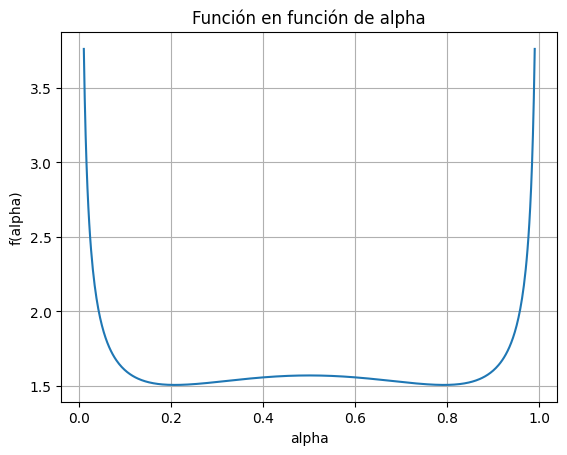

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Definimos el rango de alpha (evitamos 0 y 1 para evitar problemas numéricos)
alpha = np.linspace(0.01, 0.99, 500)

# Cuantil de la normal estándar
z_alpha = norm.ppf(alpha)

# PDF de la normal estándar evaluada en z_alpha
phi = norm.pdf(z_alpha)

# Función
f = (alpha * (1 - alpha)) / (phi**2 * (1 + 0.5 * z_alpha**2))

# Gráfica
plt.figure()
plt.plot(alpha, f)
plt.xlabel('alpha')
plt.ylabel('f(alpha)')
plt.title('Función en función de alpha')
plt.grid()

plt.show()

In [1]:
import numpy as np
import pandas as pd

from config import RAW_DATA_DIR

sp500 = pd.read_csv(RAW_DATA_DIR / "returns_SP500_ME.csv",index_col="Date", parse_dates=True).values

df_raw = pd.read_csv(RAW_DATA_DIR / "dataset_paper1_monthly.csv",index_col="Date", parse_dates=True)
ffdata_df = df_raw.loc['1926-07-01':'2001-12-01', ['Mkt-RF', 'SMB', 'HML']]

dgps = [
    ("sp500", sp500),
    ("Mkt-RF", ffdata_df["Mkt-RF"].values),
    ("SMB", ffdata_df["SMB"].values),
    ("HML", ffdata_df["HML"].values)
]

In [1]:
import numpy as np

In [2]:
def _avar_symm(sr, rho=0.2, omega=0.05, alpha=0.08, beta=0.87, exc_kurt=0, **kw):

        k_r = exc_kurt + 3
        phi = rho
        phi2 = phi**2
        den_com = 1 - 2*alpha*beta - beta**2
        
        K = (1 + phi2) * k_r - 5 * phi2 - 1
        
        num_A = 1 - alpha*beta - beta**2
        factor_A = 1 - phi2 * (alpha + beta)
        A = 6 * phi2 * alpha * (num_A / den_com) * (1 / factor_A)
        
        num = ((1 - beta)**2) * (1 + alpha + beta)
        den = (1 - alpha - beta) * den_com
        params = num / den
        
        term_params = (2/3) * A + params
        S_vv = (1 / (1 - phi2)) * (4 * phi2 + (K / (1 + A)) * term_params)

        term2 = 0.25 * sr**2 * S_vv
        term1 = (1 + phi) / (1 - phi)
        return term1 + term2

In [3]:
def _avar(sr, phi=0.2, omega=0.05, alpha=0.08, beta=0.87,
                           exc_kurt=0, skew=0, **kw):
    k_r = exc_kurt + 3.0

    # ---- shorthand ----
    rho    = alpha + beta
    phi2   = phi * phi
    om_p2  = 1.0 - phi2                          # 1 - phi^2
    om_r   = 1.0 - rho                           # 1 - alpha - beta
    den_z  = 1.0 - 2.0*alpha*beta - beta*beta    # appears in Sigma_{eta eta}
    g      = 1.0 + 2.0*phi*alpha - phi*beta      # appears in S_12 and m_1

    # =====================  S_11 / sigma^2  =====================
    S11n = (1.0 + phi) / (1.0 - phi)

    # =====================  S_12 / sigma^3  =====================
    bracket12 = 2.0*phi*alpha + (1.0 - beta) * (1.0 - phi*rho) / om_r
    S12n = skew * (1.0 + phi + phi2) / (om_p2 * g) * bracket12

    # =====================  S_22 / sigma^4  =====================
    # M_1 / sigma^4 = m1 * skew^2   (Taylor expansion of sigma_t^3 around sigma_u^3)
    m1 = (3.0 * alpha * (1.0 - phi) * (1.0 + phi + phi2)**2 * (1.0 - phi*rho)) \
         / (2.0 * (1.0 + phi) * g**2)

    # auxiliary constants from the derivation
    P = alpha * (1.0 - alpha*beta - beta*beta) / den_z
    Q = 1.0 - phi2 * rho

    # T_1, T_2 in  S_22 = T_0 + T_1 * M_1 + T_2 * K   (K = (k_u - 1) * sigma_u^4)
    T1 = (4.0 * phi / om_p2**2) * (
        2.0 * phi2 * alpha / Q  +  (1.0 - beta) / om_r
    )
    T2 = (1.0 / (om_p2**2 * den_z)) * (
        4.0 * phi2 * alpha * (1.0 - alpha*beta - beta*beta) / Q
        + (1.0 - beta)**2 * (1.0 + rho) / om_r
    )

    # eliminate K via the fourth-moment identity  E[x_t^4] = k_r * sigma^4
    denomK = Q + 6.0 * phi2 * P
    c0 = 4.0 * phi2 / om_p2 - T2 * Q * om_p2 * (1.0 + 5.0*phi2) / denomK
    ck = T2 * Q * om_p2 * (1.0 + phi2) / denomK
    cs = m1 * (T1 - 4.0 * phi * (1.0 + phi2 * (2.0*alpha - beta)) * T2 / denomK)

    S22n = c0 + ck * k_r + cs * skew * skew

    # =====================  delta-method assembly  =====================
    return S11n - sr * S12n + 0.25 * sr * sr * S22n


def _avar2(sr, phi=0.2, omega=0.05, alpha=0.08, beta=0.87,
                           exc_kurt=0, skew=0, **kw):
    k_r = exc_kurt + 3.0

    # ---- shorthand ----
    p    = alpha + beta
    phi2   = phi * phi
    om_p2  = 1.0 - phi2                          # 1 - phi^2
    om_r   = 1.0 - p                           # 1 - alpha - beta
    den_z  = 1.0 - 2.0*alpha*beta - beta*beta    # appears in Sigma_{eta eta}
    g      = 1.0 + 2.0*phi*alpha - phi*beta      # appears in S_12 and m_1

    # =====================  S_11 / sigma^2  =====================
    S11n = (1.0 + phi) / (1.0 - phi)

    # =====================  S_12 / sigma^3  =====================
    bracket12 = 2.0*phi*alpha + (1.0 - beta) * (1.0 - phi*p) / om_r
    S12n = skew * (1.0 + phi + phi2) / (om_p2 * g) * bracket12

    # =====================  S_22 / sigma^4  =====================
    # M_1 / sigma^4 = m1 * skew^2   (Taylor expansion of sigma_t^3 around sigma_u^3)
    m1 = (3.0 * alpha * (1.0 - phi) * (1.0 + phi + phi2)**2 * (1.0 - phi*p)) \
         / (2.0 * (1.0 + phi) * g**2)
    M1 = m1 * skew**2

    # auxiliary constants from the derivation
    P = alpha * (1.0 - alpha*beta - beta*beta) / den_z
    Q = 1.0 - phi2 * p

    K = (Q * (1.0 - phi2) * ((1.0 + phi2)*k_r -1-5*phi2)-4*phi*M1*(1+phi2*(2*alpha-beta))) / (Q+6*phi2*P)

    H1 = (2*phi*alpha*M1 + K*P)/Q + 1-phi2

    A = 2*phi/ (1-phi2)
    B = (1-beta)/((1-phi2)*(1-p))

    R= (1-p**2)/(1-2*alpha*beta-beta**2)

    S22n = A**2*H1 + B**2*K*R + 2*A*B*M1

    # =====================  delta-method assembly  =====================
    return S11n - sr * S12n + 0.25 * sr * sr * S22n

In [4]:
from utils.moments import ar_garch_kurtosis_from_e

In [10]:
from arch import arch_model
from arch.univariate import ConstantMean, GARCH, ARX
from arch.univariate.distribution import (
    Normal,
    StudentsT,
    SkewStudent,
)
from scipy import stats


def get_theo_mom():
    m = ARX(lags=1)
    m.volatility = GARCH(p=1, q=1)
    m.distribution = SkewStudent(seed=42)
    #m.distribution = StudentsT(seed=42)

    mu=0.5
    phi=-0.3
    const = mu * (1.0 - phi)

    # Full parameter vector: [c, phi] + [omega, alpha, beta]
    alpha = 0.1
    beta=0.85
    eta=8.0
    lamb=-0.5
    params = [const, phi, 0.05, alpha, beta, eta, lamb]
    #params = [const, phi, 0.05, alpha, beta, eta]

    result = m.simulate(params, nobs=10_000_000, burn=10000)
    sample =  result["data"].values

    skew = stats.skew(sample)
    kurt=stats.kurtosis(sample)
    std = np.sqrt((0.05/(1-alpha-beta))/(1-phi**2))
    mean=mu
    sr = mean/std

    return skew,kurt,sr

In [ ]:
std = np.sqrt((0.05/(1-alpha-beta))/(1-phi**2))

1.098901098901098

In [11]:
skew,kurt,sr = get_theo_mom()
skew,kurt,sr

(np.float64(-1.0919565145096128),
 np.float64(7.002874622932779),
 np.float64(0.476969600708473))

In [13]:
alpha = 0.1
beta=0.85
phi=-0.3

In [90]:
avar = _avar_symm(sr, rho=phi, omega=0.05, alpha=alpha, beta=beta, exc_kurt=kurt)
avar

np.float64(3.326875948456296)

In [14]:
avar = _avar2(sr, rho=phi, omega=0.05, alpha=alpha, beta=beta, exc_kurt=kurt, skew=skew)
avar

np.float64(7.64747849621312)

In [15]:
import numpy as np

from arch.univariate import ARX, GARCH, StudentsT, SkewStudent
from joblib import Parallel, delayed

# ---------------------------------------
# Parámetros globales
# ---------------------------------------
N = 50_000
T = 50000

mu = 0.5
phi = -0.3

const = mu * (1.0 - phi)
alpha = 0.1
beta = 0.85
eta = 8.0
lamb=-0.5
params = [const, phi, 0.05, alpha, beta, eta, lamb]
#params = [const, phi, 0.05, alpha, beta, eta]

def simulate_sr(seed):

    rng = np.random.default_rng(seed)

    m = ARX(lags=1)
    m.volatility = GARCH(p=1, q=1)
    m.distribution = SkewStudent(seed=rng)
    #m.distribution = StudentsT(seed=rng)

    result = m.simulate(
        params,
        nobs=T,
        burn=1000
    )
    sample = result["data"].values
    sr_h = sample.mean() / sample.std(ddof=1)
    return sr_h

master_rng = np.random.default_rng(42)
seeds = master_rng.integers(0,2**32 - 1,size=N)

srs = Parallel(n_jobs=-1, verbose=10)(
    delayed(simulate_sr)(seed)
    for seed in seeds
)

srs = np.array(srs)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done  80 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 133 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done 173 tasks      | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done 194 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done 217 tasks      | elapsed:   14.6s
[Parallel(n_jobs=-1)]: Done 240 tasks      | elapsed:  

In [16]:
np.var(srs)*T

np.float64(6.759357975099644)

In [17]:
np.mean(srs)- sr

np.float64(0.00025389842322098843)

In [120]:
np.var(srs)*T

np.float64(6.33179621571936)

In [121]:
np.mean(srs)- sr

np.float64(0.0007241296664647345)

In [122]:
Z = np.sqrt(T) * (np.array(srs) - sr) / np.sqrt(avar)

# --------------------------------
# Comprobaciones numéricas
# --------------------------------
print("Media Z:", np.mean(Z))
print("Var Z:", np.var(Z))
print("Std Z:", np.std(Z))

Media Z: 0.03702687937611744
Var Z: 0.8277486391179948
Std Z: 0.90980692408774


KstestResult(statistic=np.float64(0.08749973320984322), pvalue=np.float64(0.0), statistic_location=np.float64(0.20908673014242246), statistic_sign=np.int8(-1))


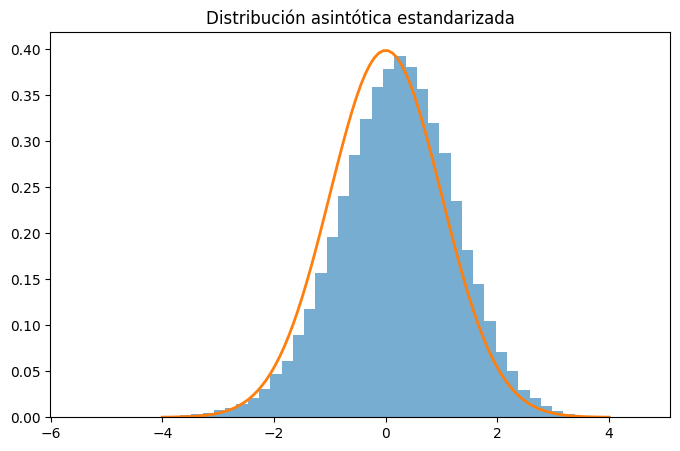

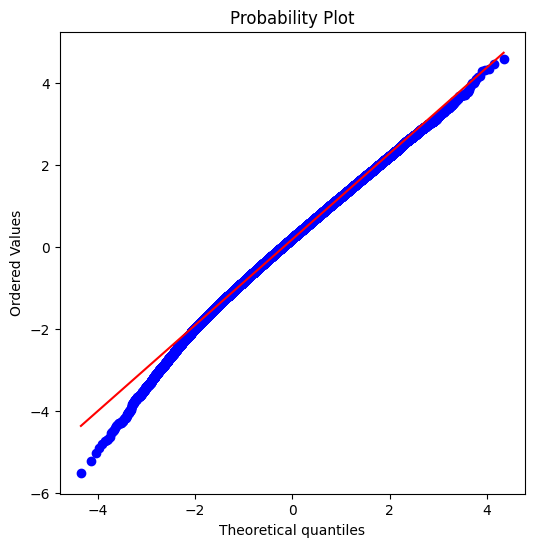

In [79]:
from scipy.stats import norm, kstest, probplot
import numpy as np
import matplotlib.pyplot as plt

ks = kstest(Z, 'norm')
print(ks)

# --------------------------------
# Histograma
# --------------------------------
x = np.linspace(-4, 4, 100)

plt.figure(figsize=(8,5))
plt.hist(Z, bins=50, density=True, alpha=0.6)
plt.plot(x, norm.pdf(x), lw=2)
plt.title("Distribución asintótica estandarizada")
plt.show()

# --------------------------------
# QQ plot
# --------------------------------
plt.figure(figsize=(6,6))
probplot(Z, dist='norm', plot=plt)
plt.show()

In [10]:
import numpy as np

from arch.univariate import ARX, GARCH
from arch import arch_model
from arch.univariate import ConstantMean, GARCH, ARX
from arch.univariate.distribution import (
    Normal,
    StudentsT,
    SkewStudent,
)
from scipy import stats


mu = 0.5
phi = -0.3

const = mu * (1.0 - phi)
alpha = 0.1
beta = 0.85
eta = 8.0
lamb=-0.2
params = [const, phi, 0.05, alpha, beta, eta, lamb]
#params = [const, phi, 0.05, alpha, beta, eta]


rng = np.random.default_rng(42)

m = ARX(lags=1)
m.volatility = GARCH(p=1, q=1)
m.distribution = SkewStudent(seed=rng)
#m.distribution = StudentsT(seed=rng)

result = m.simulate(
    params,
    nobs=10_000_000,
    burn=10000
)
sample = result["data"].values

In [11]:
skew = stats.skew(sample)
kurt = stats.kurtosis(sample)+3
skew, kurt

(np.float64(-0.4862603793193199), np.float64(7.517797913398623))

In [12]:
from utils.moments import ar_garch_moments

ep_skew = SkewStudent(seed=42).moment(3, [eta, lamb])
ep_k = SkewStudent(seed=42).moment(4, [eta, lamb])
ep_skew, ep_k

(np.float64(-0.5358681474841156), np.float64(4.811702848936486))

In [13]:
ar_garch_moments(ep_skew, ep_k, phi, alpha, beta)

(np.float64(-0.42122521965550513), np.float64(7.665605295156838))

In [17]:
am = arch_model(sample[:100000], mean='AR', lags=1, vol='GARCH',p=1,q=1, dist='skewt', rescale=True)
res = am.fit(disp="off")

In [19]:
res.params

Const       0.652620
y[1]       -0.297912
omega       0.048003
alpha[1]    0.099394
beta[1]     0.852964
eta         7.861313
lambda     -0.200483
Name: params, dtype: float64

In [21]:
ep_skew = SkewStudent(seed=42).moment(3, [res.params['eta'], res.params['lambda']])
ep_k = SkewStudent(seed=42).moment(4, [res.params['eta'], res.params['lambda']])
ep_skew, ep_k

(np.float64(-0.5433153364022996), np.float64(4.8774375504099865))

In [22]:
ar_garch_moments(ep_skew, ep_k, phi, alpha, beta)

(np.float64(-0.4270791667553765), np.float64(7.847021127539324))

In [2]:
def _avar2(sr, rho=0.2, omega=0.05, alpha=0.08, beta=0.87, exc_kurt=0, skew=0, **kw):
        k_r = exc_kurt + 3.0

        # ---- shorthand ----
        phi=rho
        p    = alpha + beta
        phi2   = phi * phi
        om_p2  = 1.0 - phi2                          # 1 - phi^2
        om_r   = 1.0 - p                           # 1 - alpha - beta
        den_z  = 1.0 - 2.0*alpha*beta - beta*beta    
        g      = 1.0 + 2.0*phi*alpha - phi*beta  

        # =====================  S_11 / sigma^2  =====================
        S11n = (1.0 + phi) / (1.0 - phi)

        # =====================  S_12 / sigma^3  =====================
        bracket12 = 2.0*phi*alpha + (1.0 - beta) * (1.0 - phi*p) / om_r
        S12n = skew * (1.0 + phi + phi2) / (om_p2 * g) * bracket12

        # =====================  S_22 / sigma^4  =====================
        # M_1 / sigma^4 = m1 * skew^2   (Taylor expansion of sigma_t^3 around sigma_u^3)
        m1 = (3.0 * alpha * (1.0 - phi) * (1.0 + phi + phi2)**2 * (1.0 - phi*p)) \
            / (2.0 * (1.0 + phi) * g**2)
        M1 = m1 * skew**2

        P = alpha * (1.0 - alpha*beta - beta*beta) / den_z
        Q = 1.0 - phi2 * p

        K = (Q * (1.0 - phi2) * ((1.0 + phi2)*k_r -1-5*phi2)-4*phi*M1*(1+phi2*(2*alpha-beta))) / (Q+6*phi2*P)

        H1 = (2*phi*alpha*M1 + K*P)/Q + 1-phi2

        A = 2*phi/ (1-phi2)
        B = (1-beta)/((1-phi2)*(1-p))

        R= (1-p**2)/(1-2*alpha*beta-beta**2)

        S22n = A**2*H1 + B**2*K*R + 2*A*B*M1

        return S11n - sr * S12n + 0.25 * sr * sr * S22n

In [32]:
def _avar(sr, rho=0.2, omega=0.05, alpha=0.08, beta=0.87, exc_kurt=0, skew=0, **kw):
    k_r = exc_kurt + 3.0
    p    = alpha + beta
    phi = rho
    phi2   = phi * phi
    om_p2  = 1.0 - phi2                          # 1 - phi^2
    om_r   = 1.0 - p                           # 1 - alpha - beta
    den_p  = 1.0 - alpha*beta - beta*beta    
    den_r  = 1.0 - 2.0*alpha*beta - beta*beta    
    g      = 1.0 + 2.0*phi*alpha - phi*beta  

    S11n = (1.0 + phi) / (1.0 - phi)

    bracket12 = 2.0*phi*alpha + (1.0 - beta) * (1.0 - phi*p) / om_r
    S12n = skew * (1.0 + phi + phi2) / (om_p2 * g) * bracket12

    W = (1-beta)/om_r
    R = (1-p**2)/den_r
    K = (1+phi2)*k_r-1-5*phi2
    Q = 1 - phi2*p
    P = alpha*den_p/den_r
    X = 6*phi2*P/Q
    sig = 2/3*X+W**2*R
    M = 1 + phi2*(2*alpha - beta)
    z_num = alpha*(1-phi*p)*(1+phi+phi2)**2*4*phi
    z_den = (1+phi)**2*g**2*Q
    Z =3/2*z_num/z_den
    N = 2*phi2*alpha + W*Q
    bracket22 = 4*phi2 + K*sig/(1+X) + skew**2*Z*(N-M/(1+X)*sig)
    S22n = bracket22/ om_p2

    return S11n - sr * S12n + 0.25 * sr * sr * S22n


In [35]:
_avar(1.5, exc_kurt=8, skew=1.7)

29.658759058072174

In [36]:
_avar2(1.5, exc_kurt=8, skew=1.7)

29.65875905807216